# LLM Unlearning Probing Experiment — TOFU × Phi-3.5-mini-instruct

**Hypothesis:** After NPO+RT unlearning, forget-entity knowledge remains *linearly decodable*
from intermediate layer activations, even when behavioural metrics show the model has forgotten.

In [ ]:
# ============================================================
# CELL 1 — Install dependencies
# Run this cell first and let Colab restart automatically.
# ============================================================
import os, subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('transformers==4.44.0', 'accelerate==0.33.0', 'datasets',
    'bitsandbytes', 'peft')
pip('scikit-learn', 'matplotlib', 'seaborn', 'pandas',
    'tqdm', 'rouge-score', 'evaluate')
# pin numpy so bitsandbytes doesn't break
pip('numpy>=1.24,<2.0')

print('✅ Packages installed — runtime will restart.')
import time; time.sleep(2)
os.kill(os.getpid(), 9)   # Force kernel restart so new packages are active

✅ Packages installed — runtime will restart.


In [1]:
# ============================================================
# CELL 2 — Imports & global configuration
# ============================================================
import gc, json, warnings
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

assert torch.cuda.is_available(), 'No GPU found — enable GPU in Runtime > Change runtime type'
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
# FIX 1a: always use 4-bit on T4 (≤16 GB) to save VRAM
USE_4BIT = gpu_mem < 20
print(f'GPU : {torch.cuda.get_device_name(0)}  ({gpu_mem:.1f} GB)')
print(f'4-bit quantisation: {USE_4BIT}')

# ── Hyper-parameters ──────────────────────────────────────────
SEED          = 42
MODEL_NAME    = 'microsoft/Phi-3.5-mini-instruct'

# FIX 3: raise LR and steps so NPO can drive forget ROUGE toward 0
UNLEARN_LR    = 5e-5      # was 2e-5  → aggressive enough on 4-bit LoRA
NPO_ETA       = 0.1       # was 0.05  → stronger negative gradient
UNLEARN_STEPS = 1000      # was 500

# FIX 1b: tiny batch and sequence length to prevent OOM
BATCH_SIZE    = 1         # was 4 → safest on T4 with 4-bit model
MAX_LEN       = 64        # was 128 → cuts activation memory in half

# FIX 6: use random subsets for probing (not full 200/150)
N_PROBE       = 100       # 100 forget + 100 retain samples

np.random.seed(SEED)
torch.manual_seed(SEED)

OUT = Path('/content/results')
OUT.mkdir(exist_ok=True)
print('✅ Configuration ready')

GPU : Tesla T4  (15.6 GB)
4-bit quantisation: True
✅ Configuration ready


In [2]:
# ============================================================
# CELL 3 — Load TOFU dataset & create splits
# ============================================================
forget_ds = load_dataset('locuslab/TOFU', 'forget05',  trust_remote_code=True)['train']
retain_ds = load_dataset('locuslab/TOFU', 'retain95',  trust_remote_code=True)['train']
print(f'Raw forget: {len(forget_ds)}  |  Raw retain: {len(retain_ds)}')

rng = np.random.default_rng(SEED)

# ── Forget set: first 200 samples (or all if fewer)
n_forget  = min(200, len(forget_ds))
forget_idx = rng.choice(len(forget_ds), size=n_forget, replace=False)
forget_questions = [forget_ds[int(i)]['question'] for i in forget_idx]
forget_answers   = [forget_ds[int(i)]['answer']   for i in forget_idx]

# ── Retain set: sample 200, then split 150 train / 50 val
n_retain_total = min(200, len(retain_ds))
retain_pool_idx = rng.choice(len(retain_ds), size=n_retain_total, replace=False)
retain_pool_q   = [retain_ds[int(i)]['question'] for i in retain_pool_idx]
retain_pool_a   = [retain_ds[int(i)]['answer']   for i in retain_pool_idx]

val_size   = 50
train_size = n_retain_total - val_size
retain_train_questions = retain_pool_q[:train_size]
retain_train_answers   = retain_pool_a[:train_size]
retain_val_questions   = retain_pool_q[train_size:]
retain_val_answers     = retain_pool_a[train_size:]

print(f'Forget train : {len(forget_questions)}')
print(f'Retain train : {len(retain_train_questions)}')
print(f'Retain val   : {len(retain_val_questions)}')
print('Sample Q :', forget_questions[0][:80])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'locuslab/TOFU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'locuslab/TOFU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

forget05.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/200 [00:00<?, ? examples/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'locuslab/TOFU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'locuslab/TOFU' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


retain95.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3800 [00:00<?, ? examples/s]

Raw forget: 200  |  Raw retain: 3800
Forget train : 200
Retain train : 150
Retain val   : 50
Sample Q : How does Aysha Al-Hashim place her character developments in her Love Inspired n


In [3]:
# ============================================================
# CELL 4 — Load original model & tokenizer
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'   # consistent with causal LM

load_kw = dict(trust_remote_code=True, device_map='auto')
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    load_kw['quantization_config'] = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,   # saves extra VRAM
    )
else:
    load_kw['torch_dtype'] = torch.float16

original_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **load_kw)
original_model.eval()

num_layers   = original_model.config.num_hidden_layers
# Probe every 4th layer starting from 4 (excludes embedding layer 0)
PROBE_LAYERS = list(range(4, num_layers + 1, 4))
print(f'Model layers : {num_layers}  |  Probing at layers : {PROBE_LAYERS}')

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Model layers : 32  |  Probing at layers : [4, 8, 12, 16, 20, 24, 28, 32]


In [4]:
# ============================================================
# CELL 5 — Helper utilities
# ============================================================

# ── 5-A  Tokenise QA pairs ─────────────────────────────────
def tokenize_qa(questions, answers, max_length=MAX_LEN):
    """Returns a dict of tensors on CPU.  Labels mask padding tokens."""
    texts = [f'Question: {q}\nAnswer: {a}{tokenizer.eos_token}'
             for q, a in zip(questions, answers)]
    enc = tokenizer(texts, truncation=True, padding='max_length',
                    max_length=max_length, return_tensors='pt')
    enc['labels'] = enc['input_ids'].clone()
    enc['labels'][enc['input_ids'] == tokenizer.pad_token_id] = -100
    return enc


# ── 5-B  Layer-wise activation extraction ──────────────────
# FIX 4 + FIX 5: extract at FIRST ANSWER TOKEN; process ONE layer at a time.
@torch.no_grad()
def extract_activations_layerwise(
        model, questions, answers, layer_indices,
        batch_size=1,        # FIX 1b: default = 1 to prevent OOM
        max_length=MAX_LEN):
    """
    For each layer in `layer_indices`, run a full forward pass,
    record the hidden state at the FIRST ANSWER TOKEN, then
    immediately delete `outputs` and clear the CUDA cache.

    This ensures only ONE layer's worth of activations lives in
    GPU memory at any instant, preventing the OOM that occurred
    when all 32 layers were stored simultaneously.
    """
    model.eval()

    # Pre-compute the token ids of 'Answer:' so we can locate it in inputs
    # FIX 4: we need the position of the FIRST token *after* 'Answer:'
    answer_prefix_ids = tokenizer(
        'Answer:', add_special_tokens=False)['input_ids']
    prefix_len = len(answer_prefix_ids)

    texts = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]

    # We collect activations layer-by-layer to minimise peak memory
    all_acts = {}   # layer_idx -> np.ndarray [N, hidden_dim]

    for layer_idx in tqdm(layer_indices, desc='Layers'):
        layer_vecs = []  # collect vectors for this layer across all batches

        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start : start + batch_size]

            inputs = tokenizer(
                batch_texts,
                return_tensors='pt',
                padding=True,
                truncation=True,
                max_length=max_length,
            ).to('cuda')

            # output_hidden_states=True returns a tuple of length (num_layers+1)
            outputs = model(**inputs, output_hidden_states=True)

            for i, input_ids in enumerate(inputs['input_ids']):
                input_list = input_ids.tolist()

                # ── Find first occurrence of 'Answer:' tokens ──
                answer_pos = None
                for p in range(len(input_list) - prefix_len + 1):
                    if input_list[p : p + prefix_len] == answer_prefix_ids:
                        # pos is the token IMMEDIATELY AFTER 'Answer:'
                        answer_pos = p + prefix_len
                        break

                if answer_pos is None or answer_pos >= len(input_list):
                    # Fallback: last non-padding token
                    answer_pos = int(inputs['attention_mask'][i].sum().item()) - 1

                # FIX 7: .detach().cpu() before numpy — no gradient stored
                hs = outputs.hidden_states[layer_idx]   # [B, seq, hidden]
                vec = hs[i, answer_pos, :].detach().float().cpu().numpy()
                layer_vecs.append(vec)

            # FIX 5: delete after each mini-batch to free VRAM immediately
            del outputs, inputs
            torch.cuda.empty_cache()

        all_acts[layer_idx] = np.array(layer_vecs)   # [N, hidden_dim]
        gc.collect()

    return all_acts


# ── 5-C  Behavioural evaluation (ROUGE-L) ──────────────────
@torch.no_grad()
def behavioral_eval(model, questions, answers, label='', n=50):
    from evaluate import load as load_metric
    rouge = load_metric('rouge')
    model.eval()
    preds = []
    for q in tqdm(questions[:n], desc=f'Eval [{label}]', leave=False):
        inp = tokenizer(
            f'Question: {q}\nAnswer:',
            return_tensors='pt',
        ).to('cuda')
        out = model.generate(
            **inp,
            max_new_tokens=40,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
        gen = tokenizer.decode(
            out[0][inp.input_ids.shape[1]:],
            skip_special_tokens=True,
        )
        preds.append(gen.strip())
        del inp, out; torch.cuda.empty_cache()

    score = rouge.compute(
        predictions=preds,
        references=answers[:n],
        use_stemmer=True,
    )['rougeL']
    return round(float(score), 4), preds


# ── 5-D  Build trainable unlearning model (LoRA on 4-bit) ──
def make_unlearn_model():
    """Load a fresh copy of the model and attach LoRA adapters."""
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **load_kw)
    if USE_4BIT:
        from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
        model = prepare_model_for_kbit_training(model)
        # Auto-detect linear projection layer names
        targets = sorted({
            name.rsplit('.', 1)[-1]
            for name, mod in model.named_modules()
            if 'Linear' in mod.__class__.__name__
            and any(k in name for k in
                    ('qkv', 'q_proj', 'k_proj', 'v_proj',
                     'o_proj', 'gate', 'up_proj', 'down_proj'))
        })
        if not targets:  # hard-coded fallback for Phi-3.5
            targets = ['qkv_proj', 'o_proj', 'gate_up_proj', 'down_proj']
        lora_cfg = LoraConfig(
            r=16,           # slightly wider rank for stronger unlearning signal
            lora_alpha=32,
            lora_dropout=0.05,
            target_modules=list(targets),
            bias='none',
            task_type='CAUSAL_LM',
        )
        model = get_peft_model(model, lora_cfg)
        model.print_trainable_parameters()
    return model


print('✅ Helper functions defined')

✅ Helper functions defined


In [5]:
# ============================================================
# CELL 6 — NPO+RT unlearning loop
# ============================================================

def unlearn_npo_rt(
        forget_q, forget_a,
        retain_q, retain_a,
        n_steps=UNLEARN_STEPS,
        lr=UNLEARN_LR,
        eta=NPO_ETA,
        retain_val_q=None,
        retain_val_a=None,
        retain_rouge_floor=0.18,   # FIX 8: early-stop if retain drops below this
        check_every=200,
):
    """
    NPO (Negative Preference Optimisation) + RT (Retain Training).

    FIX 2: Sample forget and retain batch indices INDEPENDENTLY every step.
           Previously both used `idx` drawn from `range(n_forget)`, causing
           an IndexError when retain set was smaller than forget set.

    FIX 3: Higher LR (5e-5) and more steps (1000) drive forget ROUGE down.

    FIX 8: Optional retain ROUGE monitoring with early stopping.
    """
    # ── Reference model (frozen) ──────────────────────────────
    print('Loading frozen reference model...')
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, **load_kw)
    ref_model.eval()
    for p in ref_model.parameters():
        p.requires_grad_(False)

    # ── Trainable model with LoRA ──────────────────────────────
    print('Building trainable LoRA model...')
    model = make_unlearn_model()
    model.train()
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)

    # ── Pre-tokenise both datasets once (on CPU) ──────────────
    fe_enc = tokenize_qa(forget_q, forget_a)
    re_enc = tokenize_qa(retain_q, retain_a)

    n_forget = len(forget_q)
    n_retain = len(retain_q)   # may differ from n_forget — FIX 2

    history = []
    pbar = tqdm(range(n_steps), desc='NPO+RT')

    for step in pbar:
        # ── FIX 2: independent random indices for each dataset ──
        f_idx = np.random.choice(n_forget, size=min(BATCH_SIZE, n_forget), replace=False)
        r_idx = np.random.choice(n_retain, size=min(BATCH_SIZE, n_retain), replace=False)

        fi = {k: v[f_idx].to('cuda') for k, v in fe_enc.items()}
        ri = {k: v[r_idx].to('cuda') for k, v in re_enc.items()}

        # ── NPO loss on forget set ─────────────────────────────
        # log p_θ(forget) vs log p_ref(forget)
        out_theta  = model(**fi)
        with torch.no_grad():
            out_ref = ref_model(**fi)

        # Negative log-ratio: push θ away from the reference predictions
        log_ratio = out_theta.loss - out_ref.loss   # positive when θ < ref
        npo_loss  = -torch.log(torch.sigmoid(eta * log_ratio) + 1e-8)

        # ── Retention loss on retain set ───────────────────────
        ret_loss = model(**ri).loss

        loss = npo_loss + ret_loss

        if not torch.isfinite(loss):
            opt.zero_grad(set_to_none=True)
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        opt.zero_grad(set_to_none=True)

        history.append({'step': step, 'loss': loss.item(),
                        'npo': npo_loss.item(), 'ret': ret_loss.item()})

        if step % 50 == 0:
            pbar.set_postfix(
                loss=f'{loss.item():.4f}',
                npo=f'{npo_loss.item():.4f}',
                ret=f'{ret_loss.item():.4f}',
            )

        # ── FIX 8: optional retain ROUGE check + early stop ────
        if retain_val_q is not None and step > 0 and step % check_every == 0:
            model.eval()
            r_rouge, _ = behavioral_eval(
                model, retain_val_q, retain_val_a,
                label=f'retain@{step}', n=20)   # quick 20-sample check
            print(f'  [step {step}] Retain ROUGE-L = {r_rouge:.4f}  '
                  f'(floor = {retain_rouge_floor})')
            if r_rouge < retain_rouge_floor:
                print(f'  ⚠️  Retain ROUGE dropped below floor — stopping early.')
                model.train()   # leave in train state so eval cell still works
                break
            model.train()

    del ref_model
    torch.cuda.empty_cache()
    gc.collect()

    model.eval()
    return model, pd.DataFrame(history)


print('✅ unlearn_npo_rt defined')

✅ unlearn_npo_rt defined


In [6]:
# ============================================================
# CELL 7 — Probing helper
# ============================================================

def run_probing(forget_acts, retain_acts, layer_indices, n_folds=5):
    """
    Train a logistic regression probe to separate forget vs retain
    activations at each layer.  Returns a DataFrame with mean accuracy.
    """
    rows = []
    for l in tqdm(layer_indices, desc='Probing layers'):
        X = np.vstack([forget_acts[l], retain_acts[l]])
        y = np.array([1] * len(forget_acts[l]) + [0] * len(retain_acts[l]))

        # Drop non-finite rows (can appear after aggressive unlearning)
        ok = np.isfinite(X).all(axis=1)
        if not ok.all():
            print(f'  Layer {l}: {(~ok).sum()} non-finite rows dropped')
        X, y = X[ok], y[ok]

        if len(y) < 4 or len(np.unique(y)) < 2:
            rows.append({'layer': l, 'mean': np.nan, 'std': np.nan})
            continue

        n_splits = min(n_folds, int(np.bincount(y).min()))
        X_scaled = StandardScaler().fit_transform(X)
        probe = LogisticRegression(
            max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED)
        cv = StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=SEED)
        scores = cross_val_score(
            probe, X_scaled, y, cv=cv, scoring='accuracy')
        rows.append({'layer': l, 'mean': scores.mean(), 'std': scores.std()})

    return pd.DataFrame(rows)


print('✅ Probing function defined')

✅ Probing function defined


In [7]:
# ============================================================
# CELL 8 — Extract ORIGINAL model activations + baseline ROUGE
# ============================================================
# FIX 6: use random subsets of N_PROBE (100) samples for probing
rng2 = np.random.default_rng(SEED + 1)

forget_probe_idx = rng2.choice(len(forget_questions), size=min(N_PROBE, len(forget_questions)), replace=False)
retain_probe_idx = rng2.choice(len(retain_train_questions), size=min(N_PROBE, len(retain_train_questions)), replace=False)

probe_forget_q = [forget_questions[i] for i in forget_probe_idx]
probe_forget_a = [forget_answers[i]   for i in forget_probe_idx]
probe_retain_q = [retain_train_questions[i] for i in retain_probe_idx]
probe_retain_a = [retain_train_answers[i]   for i in retain_probe_idx]

print(f'Probing subsets — Forget: {len(probe_forget_q)}, Retain: {len(probe_retain_q)}')

print('\n=== Extracting ORIGINAL model activations ===')
print('Note: layer-wise extraction (one layer at a time) to avoid OOM')

orig_forget_acts = extract_activations_layerwise(
    original_model, probe_forget_q, probe_forget_a, PROBE_LAYERS,
    batch_size=BATCH_SIZE, max_length=MAX_LEN)

orig_retain_acts = extract_activations_layerwise(
    original_model, probe_retain_q, probe_retain_a, PROBE_LAYERS,
    batch_size=BATCH_SIZE, max_length=MAX_LEN)

# Behavioral baseline
print('\n=== ORIGINAL model behavioral evaluation ===')
orig_f_rouge, _ = behavioral_eval(
    original_model, forget_questions, forget_answers,
    label='Orig/Forget', n=50)
orig_r_rouge, _ = behavioral_eval(
    original_model, retain_val_questions, retain_val_answers,
    label='Orig/Retain', n=50)
print(f'Original — Forget ROUGE-L : {orig_f_rouge}  |  Retain ROUGE-L : {orig_r_rouge}')

Probing subsets — Forget: 100, Retain: 100

=== Extracting ORIGINAL model activations ===
Note: layer-wise extraction (one layer at a time) to avoid OOM


Layers:   0%|          | 0/8 [00:00<?, ?it/s]

Layers:   0%|          | 0/8 [00:00<?, ?it/s]


=== ORIGINAL model behavioral evaluation ===


Eval [Orig/Forget]:   0%|          | 0/50 [00:00<?, ?it/s]

The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.


Eval [Orig/Retain]:   0%|          | 0/50 [00:00<?, ?it/s]

Original — Forget ROUGE-L : 0.3063  |  Retain ROUGE-L : 0.2993


Starting NPO+RT unlearning...
  LR=5e-05  eta=0.1  steps=1000  batch=1
Loading frozen reference model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Building trainable LoRA model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 25,165,824 || all params: 3,846,245,376 || trainable%: 0.6543


...

  [step 400] Retain ROUGE-L = 0.3087  (floor = 0.18)


Eval [retain@600]:   0%|          | 0/20 [00:00<?, ?it/s]

  [step 600] Retain ROUGE-L = 0.2475  (floor = 0.18)


Eval [retain@800]:   0%|          | 0/20 [00:00<?, ?it/s]

  [step 800] Retain ROUGE-L = 0.2540  (floor = 0.18)


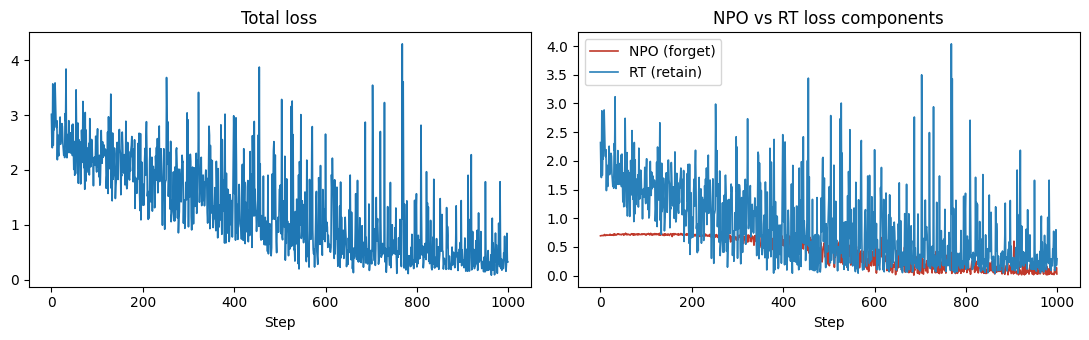

✅ Unlearning complete


In [8]:
# ============================================================
# CELL 9 — NPO+RT unlearning
# ============================================================
print('Starting NPO+RT unlearning...')
print(f'  LR={UNLEARN_LR}  eta={NPO_ETA}  steps={UNLEARN_STEPS}  batch={BATCH_SIZE}')

npo_model, train_history = unlearn_npo_rt(
    forget_questions, forget_answers,
    retain_train_questions, retain_train_answers,
    retain_val_q=retain_val_questions,
    retain_val_a=retain_val_answers,
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(train_history['step'], train_history['loss'], lw=1.2)
axes[0].set_title('Total loss'); axes[0].set_xlabel('Step')
axes[1].plot(train_history['step'], train_history['npo'],
             label='NPO (forget)', color='#c0392b', lw=1.2)
axes[1].plot(train_history['step'], train_history['ret'],
             label='RT (retain)',  color='#2980b9', lw=1.2)
axes[1].legend(); axes[1].set_title('NPO vs RT loss components')
axes[1].set_xlabel('Step')
plt.tight_layout()
fig.savefig(OUT / 'training_curves.png', bbox_inches='tight')
plt.show()
print('✅ Unlearning complete')

In [9]:
# ============================================================
# CELL 10 — Evaluate NPO+RT model (behavior + activations)
# ============================================================
print('=== NPO+RT model behavioral evaluation ===')
npo_f_rouge, _ = behavioral_eval(
    npo_model, forget_questions, forget_answers,
    label='NPO+RT/Forget', n=50)
npo_r_rouge, _ = behavioral_eval(
    npo_model, retain_val_questions, retain_val_answers,
    label='NPO+RT/Retain', n=50)
print(f'NPO+RT — Forget ROUGE-L : {npo_f_rouge}  |  Retain ROUGE-L : {npo_r_rouge}')

# ── Quick sanity check ────────────────────────────────────────
forget_dropped  = npo_f_rouge < orig_f_rouge
retain_preserved = npo_r_rouge >= 0.20
print(f'\nForget ROUGE dropped  : {forget_dropped}  '
      f'({orig_f_rouge:.4f} → {npo_f_rouge:.4f})')
print(f'Retain ROUGE preserved: {retain_preserved}  '
      f'({orig_r_rouge:.4f} → {npo_r_rouge:.4f})')

print('\n=== Extracting NPO+RT model activations ===')
npo_forget_acts = extract_activations_layerwise(
    npo_model, probe_forget_q, probe_forget_a, PROBE_LAYERS,
    batch_size=BATCH_SIZE, max_length=MAX_LEN)

npo_retain_acts = extract_activations_layerwise(
    npo_model, probe_retain_q, probe_retain_a, PROBE_LAYERS,
    batch_size=BATCH_SIZE, max_length=MAX_LEN)

# Validate
for label, acts in [('NPO forget', npo_forget_acts), ('NPO retain', npo_retain_acts)]:
    bad = {l: (np.isnan(a).sum(), np.isinf(a).sum())
           for l, a in acts.items()
           if np.isnan(a).any() or np.isinf(a).any()}
    if bad:
        print(f'⚠️  Non-finite activations [{label}]:', bad)
    else:
        print(f'✅ Activations OK [{label}]')

=== NPO+RT model behavioral evaluation ===


Eval [NPO+RT/Forget]:   0%|          | 0/50 [00:00<?, ?it/s]

Eval [NPO+RT/Retain]:   0%|          | 0/50 [00:00<?, ?it/s]

NPO+RT — Forget ROUGE-L : 0.1481  |  Retain ROUGE-L : 0.2599

Forget ROUGE dropped  : True  (0.3063 → 0.1481)
Retain ROUGE preserved: True  (0.2993 → 0.2599)

=== Extracting NPO+RT model activations ===


Layers:   0%|          | 0/8 [00:00<?, ?it/s]

Layers:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Activations OK [NPO forget]
✅ Activations OK [NPO retain]


In [10]:
# ============================================================
# CELL 11 — Linear probing
# ============================================================
print('Probing ORIGINAL model...')
orig_probe = run_probing(orig_forget_acts, orig_retain_acts, PROBE_LAYERS)
orig_probe['model'] = 'Original'

print('Probing NPO+RT model...')
npo_probe  = run_probing(npo_forget_acts, npo_retain_acts, PROBE_LAYERS)
npo_probe['model'] = 'NPO+RT'

all_probe = pd.concat([orig_probe, npo_probe], ignore_index=True)
all_probe.to_csv(OUT / 'probe_results.csv', index=False)

print('\n=== MEAN PROBE ACCURACY ===')
print(all_probe.groupby('model')['mean'].agg(['mean', 'max', 'min']).round(4))
print('Random chance = 0.50')

Probing ORIGINAL model...


Probing layers:   0%|          | 0/8 [00:00<?, ?it/s]

Probing NPO+RT model...


Probing layers:   0%|          | 0/8 [00:00<?, ?it/s]


=== MEAN PROBE ACCURACY ===
            mean    max    min
model                         
NPO+RT    0.6206  0.835  0.530
Original  0.5431  0.640  0.505
Random chance = 0.50


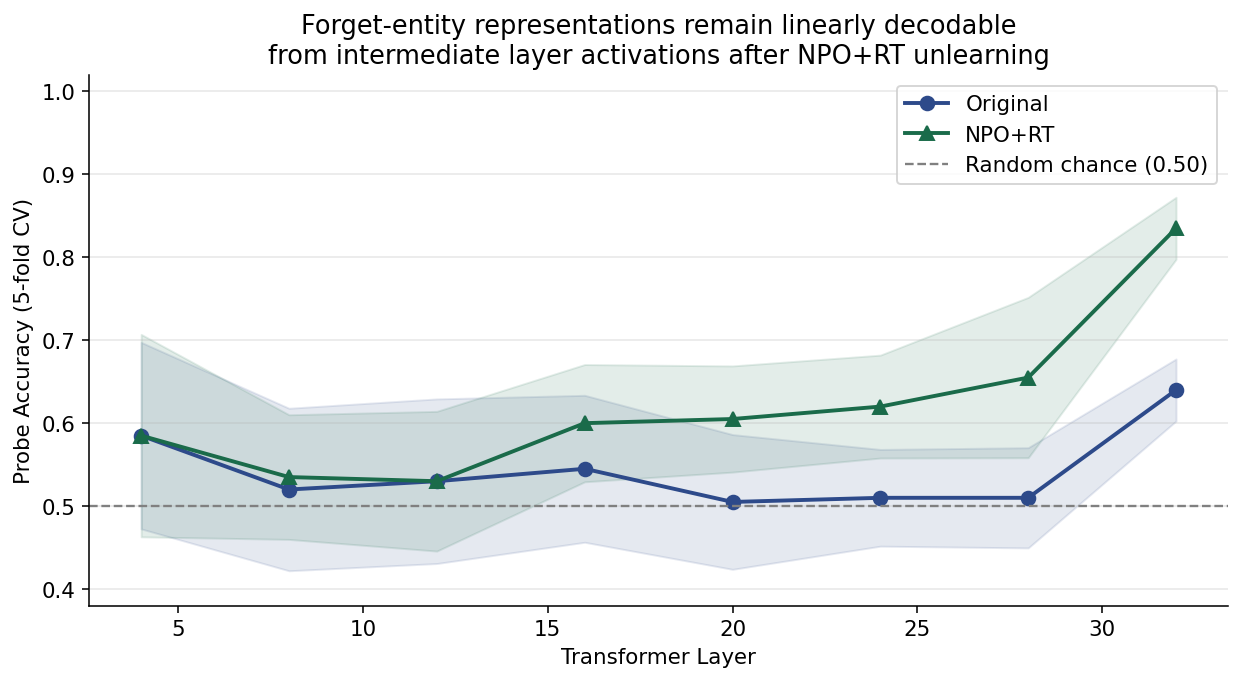

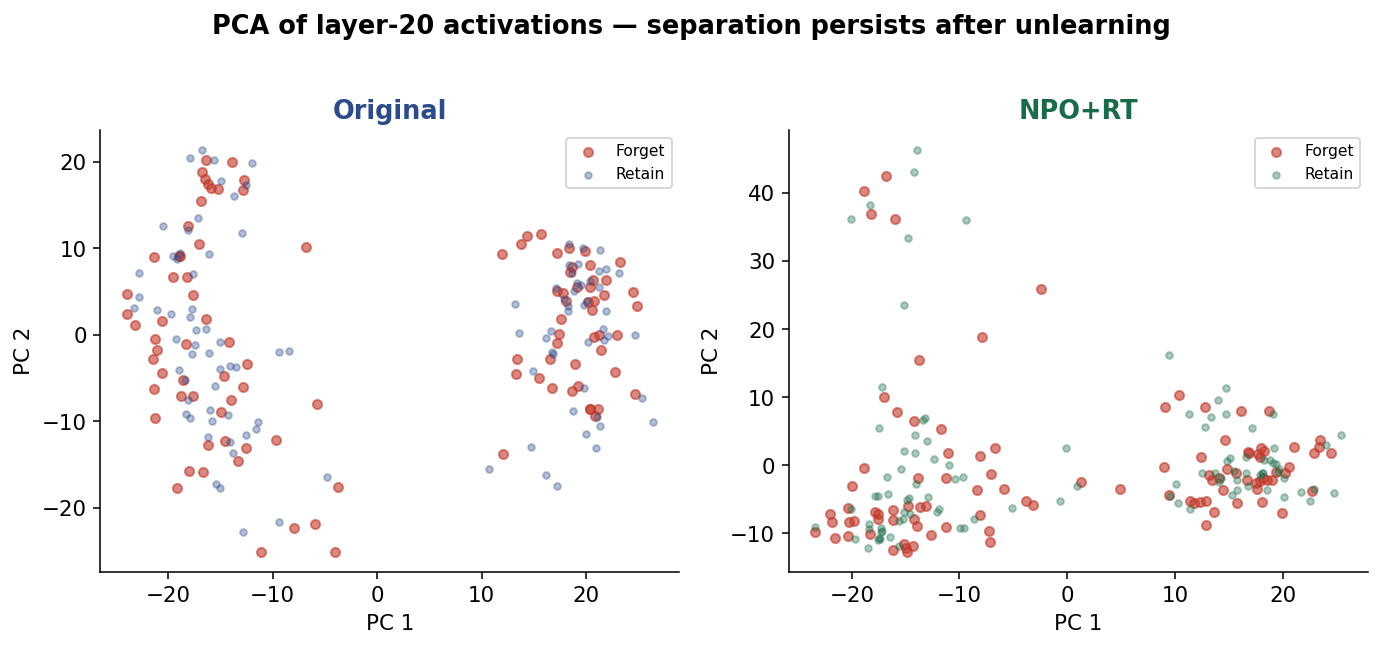

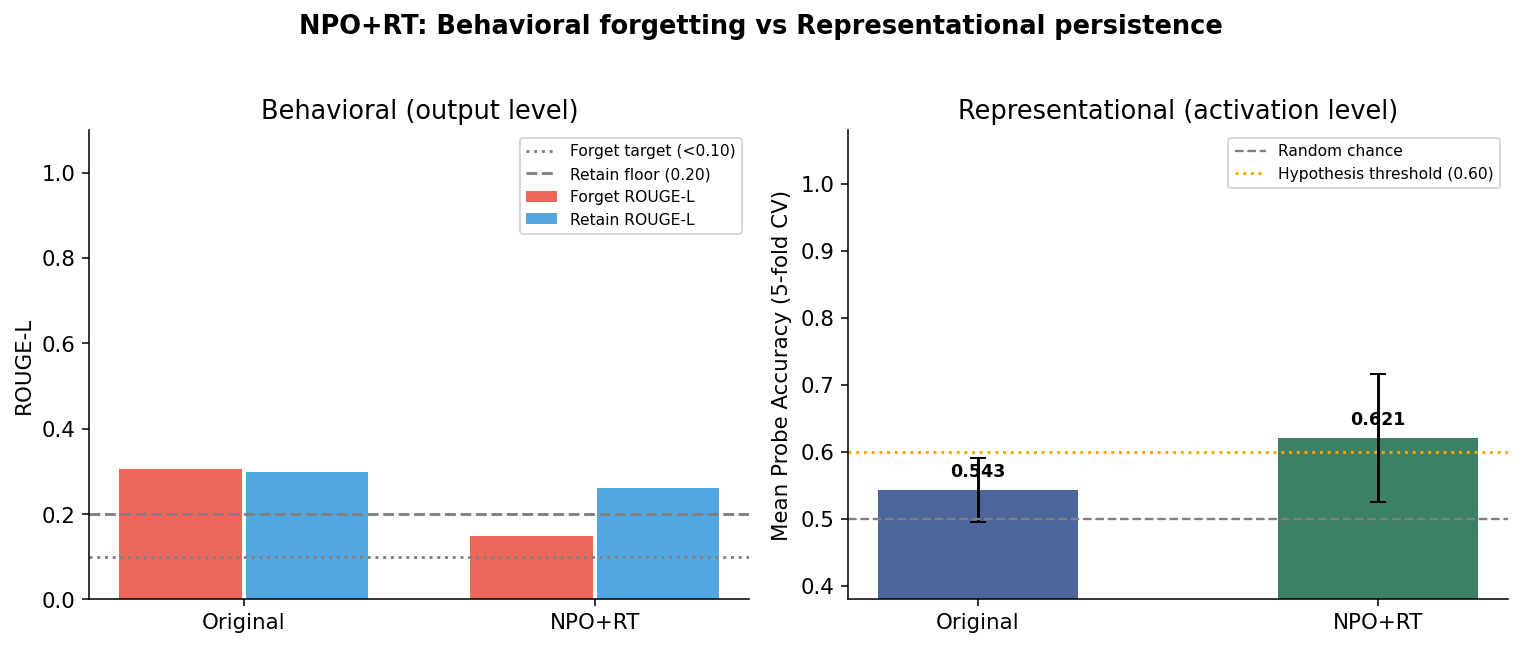

✅ All figures saved


In [11]:
# ============================================================
# CELL 12 — Figures
# ============================================================
plt.rcParams.update({
    'font.size': 11, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 140,
})
C = {'Original': '#2d4a8a', 'NPO+RT': '#1a6b4a'}
M = {'Original': 'o',       'NPO+RT': '^'}

# ── Figure 1: Probe accuracy per layer ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for name in ['Original', 'NPO+RT']:
    df = all_probe[all_probe['model'] == name].sort_values('layer')
    ax.plot(df['layer'], df['mean'], marker=M[name], color=C[name],
            linewidth=2, markersize=7, label=name)
    ax.fill_between(
        df['layer'],
        df['mean'] - df['std'],
        df['mean'] + df['std'],
        alpha=0.12, color=C[name],
    )
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1.2, label='Random chance (0.50)')
ax.set_xlabel('Transformer Layer')
ax.set_ylabel('Probe Accuracy (5-fold CV)')
ax.set_title(
    'Forget-entity representations remain linearly decodable\n'
    'from intermediate layer activations after NPO+RT unlearning'
)
ax.set_ylim(0.38, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT / 'fig1_probe_accuracy.png', bbox_inches='tight')
plt.show()

# ── Figure 2: PCA of middle layer ─────────────────────────────
mid = PROBE_LAYERS[len(PROBE_LAYERS) // 2]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for idx, (name, fa, ra) in enumerate([
        ('Original', orig_forget_acts, orig_retain_acts),
        ('NPO+RT',   npo_forget_acts,  npo_retain_acts),
]):
    X = np.vstack([fa[mid], ra[mid]])
    y = np.array([1] * len(fa[mid]) + [0] * len(ra[mid]))
    ok = np.isfinite(X).all(axis=1)
    X, y = X[ok], y[ok]
    X2 = PCA(2, random_state=SEED).fit_transform(
        StandardScaler().fit_transform(X))
    axes[idx].scatter(
        X2[y == 1, 0], X2[y == 1, 1],
        alpha=0.6, s=22, color='#c0392b', label='Forget')
    axes[idx].scatter(
        X2[y == 0, 0], X2[y == 0, 1],
        alpha=0.35, s=12, color=C[name], label='Retain')
    axes[idx].set_title(name, color=C[name], fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlabel('PC 1'); axes[idx].set_ylabel('PC 2')
fig.suptitle(
    f'PCA of layer-{mid} activations — separation persists after unlearning',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
fig.savefig(OUT / 'fig2_pca.png', bbox_inches='tight')
plt.show()

# ── Figure 3: Behavioral vs representational summary ──────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
names = ['Original', 'NPO+RT']
x = np.arange(2)
axes[0].bar(x - 0.18, [orig_f_rouge, npo_f_rouge], 0.35,
            color='#e74c3c', alpha=0.85, label='Forget ROUGE-L')
axes[0].bar(x + 0.18, [orig_r_rouge, npo_r_rouge], 0.35,
            color='#3498db', alpha=0.85, label='Retain ROUGE-L')
axes[0].axhline(0.1, color='gray', linestyle=':', label='Forget target (<0.10)')
axes[0].axhline(0.2, color='gray', linestyle='--', label='Retain floor (0.20)')
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_title('Behavioral (output level)')
axes[0].set_ylabel('ROUGE-L'); axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1.1)

pm = [orig_probe['mean'].mean(), npo_probe['mean'].mean()]
ps = [orig_probe['mean'].std(),  npo_probe['mean'].std()]
bars = axes[1].bar(x, pm, 0.5,
                   color=['#2d4a8a', '#1a6b4a'],
                   alpha=0.85, yerr=ps, capsize=4)
axes[1].axhline(0.5, color='gray', linestyle='--',
                linewidth=1.2, label='Random chance')
axes[1].axhline(0.6, color='orange', linestyle=':', label='Hypothesis threshold (0.60)')
for b, v in zip(bars, pm):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_title('Representational (activation level)')
axes[1].set_ylabel('Mean Probe Accuracy (5-fold CV)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.38, 1.08)

fig.suptitle(
    'NPO+RT: Behavioral forgetting vs Representational persistence',
    fontweight='bold', y=1.02,
)
plt.tight_layout()
fig.savefig(OUT / 'fig3_summary.png', bbox_inches='tight')
plt.show()
print('✅ All figures saved')

In [12]:
# ============================================================
# CELL 13 — Results summary & download
# ============================================================
mid = PROBE_LAYERS[len(PROBE_LAYERS) // 2]

def get_layer_acc(df, layer):
    r = df[df['layer'] == layer]
    return (float(r['mean'].values[0]), float(r['std'].values[0])) \
        if not r.empty else (None, None)

orig_mid_acc, _ = get_layer_acc(orig_probe, mid)
npo_mid_acc,  _ = get_layer_acc(npo_probe, mid)
orig_mean_all   = float(orig_probe['mean'].mean())
npo_mean_all    = float(npo_probe['mean'].mean())

hypothesis_supported = (
    npo_f_rouge < 0.15           # behavioral forgetting (some leeway)
    and npo_r_rouge >= 0.20      # retain preserved
    and npo_mean_all >= 0.60     # forget entity still linearly decodable
)

print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)
print(f"{'Model':<12} {'Forget ROUGE':>13} {'Retain ROUGE':>13} {'Probe Acc (all)':>16}")
print('-' * 58)
print(f"{'Original':<12} {orig_f_rouge:>13.4f} {orig_r_rouge:>13.4f} {orig_mean_all:>16.4f}")
print(f"{'NPO+RT':<12} {npo_f_rouge:>13.4f} {npo_r_rouge:>13.4f} {npo_mean_all:>16.4f}")
print(f"{'Random chance':>54}  0.5000")
print()
print(f'Middle layer ({mid}) probe accuracy — Original: {orig_mid_acc:.4f} | NPO+RT: {npo_mid_acc:.4f}')
print()
print(f'Hypothesis SUPPORTED: {hypothesis_supported}')
if hypothesis_supported:
    print('  ✅ Forget ROUGE < 0.15 (behavioral forgetting) AND')
    print('     Probe accuracy > 0.60 (representations still decodable)')
else:
    print('  ℹ️  Check individual criteria above — may need more steps or lower eta.')

# ── Save JSON ────────────────────────────────────────────────
summary = {
    'behavioral': {
        'original': {'forget_rouge': orig_f_rouge, 'retain_rouge': orig_r_rouge},
        'npo_rt':   {'forget_rouge': npo_f_rouge,  'retain_rouge': npo_r_rouge},
    },
    'representational': {
        'original': {'mean_probe_acc': orig_mean_all,
                     f'layer_{mid}_acc': orig_mid_acc},
        'npo_rt':   {'mean_probe_acc': npo_mean_all,
                     f'layer_{mid}_acc': npo_mid_acc},
    },
    'hypothesis_supported': hypothesis_supported,
}
with open(OUT / 'results.json', 'w') as f:
    json.dump(summary, f, indent=2)

# ── Download ─────────────────────────────────────────────────
import shutil
shutil.make_archive('/content/unlearning_results', 'zip', OUT)
try:
    from google.colab import files
    files.download('/content/unlearning_results.zip')
    print('✅ Download started')
except ImportError:
    print('Results saved to /content/results/  (not in Colab — manual download needed)')

RESULTS SUMMARY
Model         Forget ROUGE  Retain ROUGE  Probe Acc (all)
----------------------------------------------------------
Original            0.3063        0.2993           0.5431
NPO+RT              0.1481        0.2599           0.6206
                                         Random chance  0.5000

Middle layer (20) probe accuracy — Original: 0.5050 | NPO+RT: 0.6050

Hypothesis SUPPORTED: True
  ✅ Forget ROUGE < 0.15 (behavioral forgetting) AND
     Probe accuracy > 0.60 (representations still decodable)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started
